# Multi-scale decomposition of sea ice concentration using mrCOSTS

This notebook reproduces the mrCOSTS-based figures from the Ice DMD manuscript. The mrCOSTS method is used to diagnose the multi-scale properties of SIC around Antarctica. 

To run this notebook you must specifically include the coarsened and sub-sampled data `coarsened-15day.all-years.v2024-09-20.nc` in the data folder. Additionally, you must set the `fit` flag in the mrCOSTS fit section to `True`. Then the notebook will run through the mrCOSTS fitting routine. The mrCOSTS fits are not included as the files are large but inexpensive to recreate locally.


In [1]:
import copy
import glob
import os
import string
import sys
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr
from matplotlib.dates import DateFormatter
from pydmd import mrcosts
from scipy import signal as signal_processing

warnings.filterwarnings("ignore")

## Set up

### Directories

In [2]:
try:
    # This throws an error if we are not in a notebook
    exe_type = get_ipython().__class__.__name__

    # Proceed using the logic that works for a notebook
    os.chdir(os.path.join(".."))
    dir_ice = os.getcwd()

except NameError:
    # Otherwise we use the logic for a python executable
    dir_ice = os.path.abspath(os.path.join(os.path.dirname(__file__), ".."))

dir_ice_data = os.path.join(dir_ice, "data")
dir_results = os.path.join(dir_ice_data, "mrCOSTS fits")
dir_print = os.path.join(dir_ice, "figures")


### Format figures

In [3]:
# Set the plot style from the seaborn library
sns.set_style("whitegrid")
context = "paper"
sns.set_context(context, font_scale=0.8)

# Tol bright color scheme reordered to put my favorite colors first
tol_bright_reorder = [
    "#4477AA",
    "#CCBB44",
    "#EE6677",
    "#228833",
    "#66CCEE",
    "#AA3377",
    "#BBBBBB",
]
sns.set_palette(sns.color_palette(tol_bright_reorder))

alphabet = string.ascii_lowercase
lines = ["-", "--", "-.", ":"]

# Load Data

This points to the data I prepared for fitting mrCOSTS

In [4]:
print("=" * 60)
print("loading observations...")
print("")
os.chdir(dir_ice_data)
ds_obs = xr.open_dataset("coarsened-15day.all-years.v2024-09-20.nc")
data_name = "coarsened-15day.all-years"
ds_obs

loading observations...



<xarray.Dataset> Size: 36MB
Dimensions:        (time: 866, x: 72, y: 72)
Coordinates:
  * x              (x) float64 576B -0.4942 -0.4803 -0.4664 ... 0.4803 0.4942
  * y              (y) float64 576B -0.4942 -0.4803 -0.4664 ... 0.4803 0.4942
  * time           (time) datetime64[ns] 7kB 1989-01-01 ... 2024-07-11
Data variables:
    concentration  (time, x, y) float64 36MB ...

In [5]:
ds_obs = ds_obs.where(ds_obs.sum(dim=["time"]) > 0, drop=True)
ds_obs = xr.where(np.isnan(ds_obs), 0, ds_obs)

In [6]:
# Extract out data to fit
data_3d = ds_obs.transpose("x", "y", "time").concentration.values
data_1d = data_3d.reshape(ds_obs.x.size * ds_obs.y.size, ds_obs.time.size)

# Don't bother to fit locations without sea ice
not_zero = data_1d.sum(axis=1) > 0
not_zerodex_1d = np.flatnonzero(not_zero)
data_to_fit = data_1d[not_zerodex_1d, :]

# Time series in units of days
ts = ds_obs.time
ts = ts - ts.isel(time=0)
ts = (ts / (1e9 * 60 * 60 * 24)).values.astype(float)

# Time step in days
dt_days = 15

# mrCOSTS

## Set hyperparameters

In [7]:
# Window size (in time steps)
window_lengths = np.array([12, 25, 50, 100, 200, 400])
step_sizes = np.array([1, 2, 5, 10, 10, 10])
svd_ranks = [6, 10, 10, 10, 10, 10]
num_decompositions = len(window_lengths)
global_svd_array = [False] * len(window_lengths)
pydmd_kwargs = {
    "eig_constraints": {"conjugate_pairs", "limited"},
    "real_eig_limit": 0.01,
}
mrcosts_name = "ice-mrcosts.v2024-12-11"
num_frequency_bands = [3, 5, 5, 5, 5, 5]
kern_method = "flat"
relative_filter_length = 4

## Fit

In [8]:
# Set fit to True in order to run mrCOSTS, otherwise it uses the saved mrCOSTS fit.
fit = False
if fit:
    print("=" * 60)
    print("fitting mrCOSTS...")
    print("")
    mrc = mrCOSTS(
        svd_rank_array=svd_ranks,
        window_length_array=window_lengths,
        step_size_array=step_sizes,
        global_svd_array=global_svd_array,
        transform_method="absolute",
        pydmd_kwargs=pydmd_kwargs,
        n_components_array=num_frequency_bands,
        kern_method=kern_method,
        relative_filter_length=relative_filter_length,
    )

    mrc.fit(data_to_fit, np.atleast_2d(ts))
else:
    print("=" * 60)
    print("skipping fitting mrCOSTS...")
    print("")

skipping fitting mrCOSTS...



## Load

In [9]:
# Load the mrCOSTS fits specified by `mrcosts_name`
print("=" * 60)
print("loading mrCOSTS results...")
print("")

os.chdir(dir_results)
filename = ".".join([data_name, mrcosts_name])
file_list = glob.glob(filename + "*.nc")

if len(file_list) == 0:
    print(
        "mrCOSTS fits could not be found. mrCOSTS must be fit prior to proceeding by setting `fit=True`."
    )
    sys.exit(1)

# If mrCOSTS was fit overwrite any pre-existing fit files with the same name.
if fit:
    file_list = glob.glob(filename + "*.nc")
    for f in file_list:
        os.remove(f)
    mrc.to_netcdf(filename)

mrc = mrcosts.mrCOSTS()
mrc.from_netcdf(file_list)

loading mrCOSTS results...



# Scale-wise reconstruction

## Scale separation

In [10]:
print("=" * 60)
print("Building scale-aware reconstructions...")
print("")

Building scale-aware reconstructions...



In [11]:
# Use the silhouette score to find the optimal number of frequency bands. Often
# these will need to be combined into aggregated bands at a later stage in analysis
# but here we go for unsupervised approach when discovering the bands in the first place.
sweep_flag = False
if sweep_flag:
    n_components_range = np.arange(6, 18)
    scores, n_optimal = mrc.global_cluster_hyperparameter_sweep(
        n_components_range, transform_method="log10"
    )

    print("Optimal silhouette score is = {}".format(n_optimal))
    plt.figure(figsize=(5, 2.5))
    plt.plot(n_components_range, scores)
    plt.gca().set_xlabel("n_components (-)")
    plt.gca().set_xlabel("Silhouette score (-), (1 is best, -1 is worst)")

else:
    # Found this to be the optimal number of bands previously
    n_optimal = 14

In [12]:
cluster_centroids, omega_classes, omega_array = mrc.global_cluster_omega(
    n_optimal, transform_method="log10"
)
cluster_centers_periods = 1 / (10 ** (cluster_centroids) / (2 * np.pi) * 365)

## stacking and unstacking

Because we fit on the flattened 1D array with the all-zero points removed, we have to do a bit of book keeping here to reconstruct the 3D array. I use the `xarray` package at the end of this due to its flexibility for dealing with labeled n-arrays.

In [13]:
def xarray_unstacked(x, time, x_ragged, y_ragged):
    ds_unstacked = xr.DataArray(
        x,
        coords={"time": time},
        dims=["xy", "time"],
    )

    ds_unstacked.coords["x"] = ("xy", x_ragged.data)
    ds_unstacked.coords["y"] = ("xy", y_ragged.data)
    ds_unstacked = ds_unstacked.set_index(xy=("x", "y")).unstack("xy")

    return ds_unstacked

In [14]:
# Similar to the above but we grab the 2D indices instead of the flatttened 1D array indices.
# Specifically we select for the portion of the data not masked due to being all zero.
not_zero_2d = data_3d.sum(axis=(2)) > 0
ind_x, ind_y = np.nonzero(not_zero_2d)
n_space = len(ind_x)
n_time = len(ds_obs.time)
x_ragged = ds_obs.x.isel(x=ind_x)
y_ragged = ds_obs.y.isel(y=ind_y)

## Scale and global reconstructions

These cells create the ragged list of band classifications (`omega_classes_list`), the scale separated reconstruction (`xr_sep`), the slowly evolving background mode which wasn't captured by mrCOSTS (`xr_background`), and the global reconstruction of the data (the sum of all frequency bands in `xr_sep` together with `xr_background`).

In [15]:
omega_classes_list = mrc.multi_res_deterp()
xr_sep = mrc.global_scale_reconstruction()
xr_background = mrc.get_background()
xr_global = xr_sep.sum(axis=(0, 1)) + xr_background

Next I convert these to `xarray.Dataset`. This format makes it easier to work with the multi-dimensional data.

In [16]:
ds_background = xarray_unstacked(
    xr_background,
    ds_obs.time.values,
    x_ragged,
    y_ragged,
)
ds_background = xr.where(np.isnan(ds_background), 0, ds_background)

In [17]:
ds_global = xarray_unstacked(
    xr_global,
    ds_obs.time.values,
    x_ragged,
    y_ragged,
)
ds_global = xr.where(np.isnan(ds_global), 0, ds_global)

In [18]:
# Build a full data set by band
cc_periods = np.round(cluster_centers_periods, 2)
ds_list = []

for ncl_center, cl_center in enumerate(cluster_centers_periods):

    # Reconstruction
    ds = xarray_unstacked(
        xr_sep.sum(axis=0)[ncl_center],
        ds_obs.time.values,
        x_ragged,
        y_ragged,
    )
    ds = xr.where(np.isnan(ds), 0, ds)
    # ds = ds.to_dataset(name="concentration")
    ds.coords["bands"] = cc_periods[ncl_center]
    ds_list.append(ds)

ds_xr_bands = xr.concat(ds_list, dim="bands")

In [19]:
ice_exists_index = ds_obs.concentration.sum(dim="time") > 0

## Global reconsctruction evaluation (Fig. S1)

Creating Figure S1...



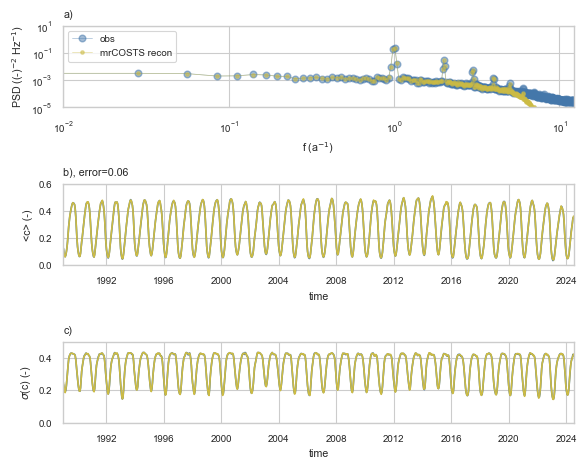

In [20]:
print("=" * 60)
print("Creating Figure S1...")
print("")

cm = 1 / 2.54  # centimeters in inches
fig, axes = plt.subplots(3, 1, figsize=(15 * cm, 12 * cm), constrained_layout=True)
date_format = DateFormatter("%Y")

ax = axes[0]
fs = 1 / (np.diff(ts)[0] / 365.24)
f, Pxx_den = signal_processing.welch(data_to_fit, fs, nperseg=1024, average="median")
ax.loglog(
    f,
    np.median(Pxx_den, axis=0),
    color=tol_bright_reorder[0],
    lw=0.5,
    marker="o",
    alpha=0.5,
    label="obs",
)
f, Pxx_den = signal_processing.welch(xr_global, fs, nperseg=1024, average="median")
ax.loglog(
    f,
    np.median(Pxx_den, axis=0),
    color=tol_bright_reorder[1],
    lw=0.5,
    marker=".",
    alpha=0.5,
    label="mrCOSTS recon",
)

ax.legend(loc="upper left")
ax.set_ylabel(r"PSD ((-)$^{-2}$ Hz$^{-1}$)")
ax.set_title("a)", loc="left")
ax.set_ylim(10**-5, 10**1)
ax.set_xlim(10**-2, f.max())
ax.set_xlabel(r"f (a$^{-1}$)")

ax = axes[1]
ax.plot(
    ds_global.time,
    ds_global.where(ice_exists_index, drop=True).mean(dim=["x", "y"]),
    color=tol_bright_reorder[0],
)
ax.plot(
    ds_obs.time,
    ds_obs.where(ice_exists_index, drop=True).concentration.mean(dim=["x", "y"]),
    color=tol_bright_reorder[1],
)
ax.set_ylabel("<c> (-)")
ax.set_ylim(0, 0.6)
ax.xaxis.set_major_formatter(date_format)
error = mrc.costs_array[0].relative_error(xr_global, data_to_fit)
ax.set_title(f"b), error={error:.2f}", loc="left")
ax.set_xlabel("time")
ax.set_xlim(
    ds_obs.time[0].values, ds_obs.where(ice_exists_index, drop=True).time[-1].values
)

ax = axes[2]
ax.plot(
    ds_global.time,
    ds_global.where(ice_exists_index, drop=True).std(dim=["x", "y"]),
    color=tol_bright_reorder[0],
)
ax.plot(
    ds_obs.time,
    ds_obs.where(ice_exists_index, drop=True).concentration.std(dim=["x", "y"]),
    color=tol_bright_reorder[1],
)
ax.set_ylabel("$\sigma$(c) (-)")
ax.set_ylim(0, 0.5)
ax.set_title(f"c)", loc="left")
ax.xaxis.set_major_formatter(date_format)
ax.set_xlabel("time")
ax.set_xlim(ds_obs.time[0].values, ds_obs.time[-1].values)

plt.tight_layout()

os.chdir(dir_print)
fig.savefig(f"S1.mrCOSTS-fit-eval.png", dpi=300, bbox_inches="tight")
fig.savefig(f"S1.mrCOSTS-fit-eval.pdf", bbox_inches="tight")

So we nicely capture the lower order statistical moments and all of the relevant time scales using the mrCOSTS fit. The higher frequencies are not captured, but this is unsurprising as we aggregated to 15 days anyway and these high frequencies are right around the limit of what DMD can model for short time windows.

## Band amplitudes (Figure 4)

The mrCOSTS bands have different temporal resolutions, makiong a straight histogram comparison between band amplitudes misleading. This function interpolates the amplitudes to a common time step, in essence weighting the lower-resolution bands the same as the higher-resolution bands.

In [21]:
def multi_res_interp_amplitudes(
    mrc,
):
    """Multi-resolution interpolation of the mrCOSTS band amplitudes."""

    b_alone = np.zeros(
        (
            mrc.n_decompositions,
            mrc._n_components_global,
            np.max(mrc._svd_rank_array),
            mrc._n_time_steps,
        ),
        np.complex128,
    )

    omega_classes_list = mrc.multi_res_deterp()
    for n_mrd, mrd in enumerate(mrc._costs_array):
        # Track the total contribution from all windows to each time step
        xn = np.zeros(mrc._n_time_steps)
        omega_classes = omega_classes_list[n_mrd]

        if mrd.svd_rank < np.max(mrc._svd_rank_array):
            truncate_slice = slice(None, mrd.svd_rank)
            omega_classes = omega_classes[:, truncate_slice]

        # Iterate over each window slide performed.
        for k in range(mrd.n_slides):
            b = mrd.amplitudes_array[k]
            classification = omega_classes[k]

            # Compute each segment of xr starting at "t = 0"
            t = mrd.time_array[k]
            t_start = mrd.time_array[k, 0]
            t = t - t_start

            # Get the indices for this window.
            if k == mrd.n_slides - 1 and mrd._non_integer_n_slide:
                # Handle non-integer number of window slides by slightly
                # shortening the last window's slide.
                window_indices = slice(-mrd.window_length, None)
            else:
                window_indices = slice(
                    k * mrd.step_size,
                    k * mrd.step_size + mrd.window_length,
                )

            # Convolve each windowed reconstruction with a gaussian filter.
            # Weights points in the middle of the window and de-emphasizes the
            # edges of the window.
            if k == 0:
                direction = "backward"
            elif k == mrd.n_slides - 1:
                direction = "forward"
            else:
                direction = None
            recon_filter = mrd.build_kern(
                mrd.window_length,
                relative_filter_length=mrd._relative_filter_length,
                direction=direction,
            )

            for j in np.arange(0, mrc._n_components_global):
                class_bool = classification == j

                # Assign the DMD components
                if any(class_bool):
                    class_ind = np.flatnonzero(class_bool)
                    b_local = b[class_ind].real

                    for r in class_ind:
                        b_alone[n_mrd, j, r, window_indices] += (
                            np.linalg.multi_dot(
                                [
                                    b[r],
                                    np.exp(0 * t),
                                ]
                            )
                            * recon_filter
                        )

            # A normalization factor which weights the global reconstruction
            # by the number of window centers it contains. This accounts
            # for the convolution above.
            xn[window_indices] += recon_filter

        # Normalize by the reconstruction filter.
        b_alone[n_mrd] = b_alone[n_mrd] / xn

    # Sum over the band and rank dimension
    return b_alone.sum(axis=(0, 2))

In [22]:
b_alone = multi_res_interp_amplitudes(mrc)

ds_amp = xr.Dataset(
    {
        "b": (["bands", "time"], b_alone.real),
    },
    coords={
        "x": ds_obs.x.values,
        "y": ds_obs.y.values,
        "time": ds_obs.time.values,
        "bands": ds_xr_bands.bands.values,
    },
)

Creating Figure 4...



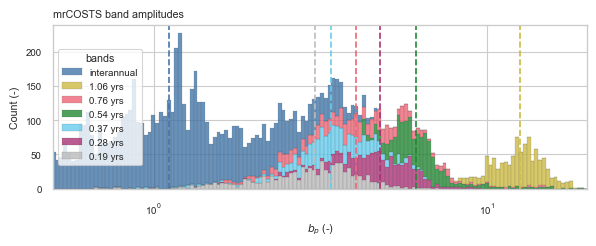

In [23]:
print("=" * 60)
print("Creating Figure 4...")
print("")

## -------------------------------------------------------------------------
# Amplitudes histogram
fig, ax = plt.subplots(1, 1, figsize=(6, 2.5))

da = ds_amp.b
da = xr.where(da == 0, 10**-8, da)
df_plot = da.to_dataframe().reset_index()
df_plot["bands"] = df_plot["bands"].where(df_plot.bands < 1.1, "interannual")
df_plot["bands"] = df_plot["bands"].astype(str)
df_plot["bands"] = [
    f"{b} yrs" if ("interannual" not in b) else f"{b}" for b in df_plot["bands"]
]
bands = list(reversed(np.unique(df_plot.bands)))
palette = sns.color_palette("cubehelix", n_colors=len(bands))
color_counter = 0

g = sns.histplot(
    data=df_plot,
    x="b",
    hue="bands",
    log_scale=(True, False),
    binrange=(-0.8, 1.5),
    bins=200,
    multiple="stack",
    palette=tol_bright_reorder,
    edgecolor=".3",
    linewidth=0.1,
    alpha=0.8,
)
ax.set_ylabel("Count (-)")
ax.set_xlabel(r"$b_p$ (-)")
ax.set_title("mrCOSTS band amplitudes", loc="left")
ax.set_xlim(0.5, 20)
sns.move_legend(g, "center left")

df_grouped = df_plot.groupby("bands").median()["b"]
for n_bp, b_p in enumerate(bands):
    ax.axvline(df_grouped[b_p], ls="--", color=tol_bright_reorder[n_bp])

plt.tight_layout()

os.chdir(dir_print)
fig.savefig("fig4.mrCOSTS_band-amplitudes.png", dpi=300, bbox_inches="tight")
fig.savefig("fig4.mrCOSTS_band-amplitudes.pdf", dpi=300, bbox_inches="tight")

# Anomalies and long-term trends

## Calculate extents

In [24]:
print("=" * 60)
print("Creating Figure 2...")
print("")

Creating Figure 2...



In [25]:
ds_obs.coords["x_km"] = ("x", np.arange(0, len(ds_obs.x)) * 25 * 6)
ds_obs.coords["y_km"] = ("y", np.arange(0, len(ds_obs.y)) * 25 * 6)

ds_annual = ds_xr_bands.where(ds_xr_bands.bands < 1.2, drop=True)
ds_annual.coords["x_km"] = ("x", np.arange(0, len(ds_obs.x)) * 25 * 6)
ds_annual.coords["y_km"] = ("y", np.arange(0, len(ds_obs.y)) * 25 * 6)

ds_inter = ds_xr_bands.where(ds_xr_bands.bands > 1.2, drop=True)
ds_inter.coords["x_km"] = ("x", np.arange(0, len(ds_obs.x)) * 25 * 6)
ds_inter.coords["y_km"] = ("y", np.arange(0, len(ds_obs.y)) * 25 * 6)

ds_background.coords["x_km"] = ("x", np.arange(0, len(ds_obs.x)) * 25 * 6)
ds_background.coords["y_km"] = ("y", np.arange(0, len(ds_obs.y)) * 25 * 6)

obs_extent = ds_obs.concentration.integrate("x_km").integrate("y_km") / 10**6
xr_interannual_extent = ds_inter.integrate("x_km").integrate("y_km") / 10**6
xr_annual_extent = ds_annual.integrate("x_km").integrate("y_km") / 10**6
xr_background_extent = ds_background.integrate("x_km").integrate("y_km") / 10**6

## Calculate anomalies

In [26]:
# Observed monthly anomalies
monthly_means = obs_extent.groupby("time.month").mean()
grouped_spatial_mean = obs_extent.groupby("time.month")
monthly_anomaly = grouped_spatial_mean - monthly_means
monthly_anom_rolling = monthly_anomaly.rolling(
    time=int(2 * (365) // 15), center=True, min_periods=10
).mean()

# Background anomaly
xr_background_extent_anom = xr_background_extent - xr_background_extent.mean()

# Interannual anoamlies
xr_interannual_extent_anom = xr_interannual_extent - xr_interannual_extent.mean(
    dim="time"
)

In [27]:
xr_all_interannual = xr_interannual_extent_anom.where(
    (xr_interannual_extent_anom.bands > 2.5) & (xr_interannual_extent_anom.bands < 20),
    drop=True,
).sum(dim="bands")
xr_supra = xr_interannual_extent_anom.where(
    (xr_interannual_extent_anom.bands < 2.5), drop=True
).sum(dim="bands")
xr_enso = xr_interannual_extent_anom.where(
    (xr_interannual_extent_anom.bands > 2.5) & (xr_interannual_extent_anom.bands < 8),
    drop=True,
).sum(dim="bands")
xr_decadal = xr_interannual_extent_anom.where(
    (xr_interannual_extent_anom.bands > 8) & (xr_interannual_extent_anom.bands < 20),
    drop=True,
).sum(dim="bands")
xr_background_edit = xr_background_extent_anom + xr_interannual_extent_anom.sel(
    bands=23, method="nearest"
)

xr_modes = [xr_enso, xr_decadal]
xr_labels = [
    r"$\tilde{x}_{2-8y}$",
    r"$\tilde{x}_{8-16y}$",
]

## Inteannual variability (Figure 2)

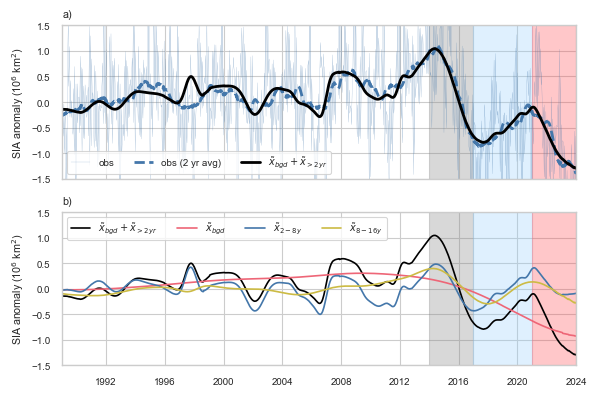

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(6, 4), sharex=True)

# --------------------------------------------------------------------------------
# Anomalies + long-time scale components
ax = axes[0]
monthly_anomaly.plot(ax=ax, label="obs", lw=0.1, color=tol_bright_reorder[0])
monthly_anom_rolling.plot(
    ax=ax, label="obs (2 yr avg)", lw=2, color=tol_bright_reorder[0], ls="--"
)

(xr_background_edit + xr_all_interannual).plot(
    ax=ax,
    label=r"$\tilde{x}_{bgd} + \tilde{x}_{>2yr}$",
    color="k",
    lw=2,
)
ax.set_ylabel("SIA anomaly (10$^6$ km$^2$)")
ax.fill_between(
    [pd.Timestamp("2014-01-1"), pd.Timestamp("2017-01-1")],
    -4,
    4,
    alpha=0.3,
    color="0.5",
)
ax.fill_between(
    [pd.Timestamp("2017-01-1"), pd.Timestamp("2021-01-1")],
    -4,
    4,
    alpha=0.3,
    color="xkcd:light blue",
)
ax.fill_between(
    [pd.Timestamp("2021-01-1"), pd.Timestamp("2024-01-1")],
    -4,
    4,
    alpha=0.3,
    color="xkcd:light red",
)
ax.legend(loc="lower left", ncols=3)
ax.set_title("")
ax.set_title("a)", loc="left")
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel("")

# --------------------------------------------------------------------------------
# Band components
ax = axes[1]

(xr_all_interannual + xr_background_edit).plot(
    ax=ax, label=r"$\tilde{x}_{bgd} + \tilde{x}_{>2yr}$", color="k"
)
xr_background_edit.plot(ax=ax, label=r"$\tilde{x}_{bgd}$", color=tol_bright_reorder[2])

for nds, ds in enumerate(xr_modes):
    label = xr_labels[nds]
    ds.plot(label=label)

ax.fill_between(
    [pd.Timestamp("2014-01-1"), pd.Timestamp("2017-01-1")],
    -4,
    4,
    alpha=0.3,
    color="0.5",
)
ax.fill_between(
    [pd.Timestamp("2017-01-1"), pd.Timestamp("2021-01-1")],
    -4,
    4,
    alpha=0.3,
    color="xkcd:light blue",
)
ax.fill_between(
    [pd.Timestamp("2021-01-1"), pd.Timestamp("2024-01-1")],
    -4,
    4,
    alpha=0.3,
    color="xkcd:light red",
)

ax.set_title("")
ax.legend(ncols=5, loc="upper left")
ax.set_ylabel("SIA anomaly (10$^6$ km$^2$)")
ax.set_xlabel("")
ax.set_xlim(pd.Timestamp("1989-01-01"), pd.Timestamp("2024-01-01"))
ax.set_ylim(-1.5, 1.5)
ax.set_title("b)", loc="left")

fig.tight_layout()

os.chdir(dir_print)
fig.savefig("fig2.mrCOSTS-diagnostic.long-term.png", dpi=300, bbox_inches="tight")
fig.savefig("fig2.mrCOSTS-diagnostic.long-term.pdf", bbox_inches="tight")

# Spatial pattern of the background mode

## Prep plotted quantities

In [29]:
print("=" * 60)
print("Creating Figure 3...")
print("")

Creating Figure 3...



In [30]:
ds_background_coarse = (
    ds_background.where(ds_background.sum(dim="time") > 0)
    .coarsen(x=4, y=4, boundary="trim")
    .mean()
)
ds_background_coarse = ds_background_coarse.to_dataset(name="concentration")

pixel_count = (
    ds_background.isel(time=0).where(ds_background.sum(dim="time") > 0)
    # .coarsen(x=2, y=2, boundary="trim")
    .count()
)

ds_background_coarse = ds_background_coarse.where(pixel_count > 8, drop=True)


x_lin = np.linspace(0, 1, len(ds_background_coarse.x))
y_lin = np.linspace(0, 1, len(ds_background_coarse.y))
x_grid, y_grid = np.meshgrid(x_lin, y_lin)
colors = np.array(
    [
        np.ones((len(ds_background_coarse.x), len(ds_background_coarse.y))) * 0.5,
        1 - x_grid,
        1 - y_grid,
    ]
).T

ds_background_coarse["colors"] = (("x", "y", "rgb"), colors)
ds_background_coarse = ds_background_coarse.where(
    ds_background_coarse.concentration.sum(dim="time") > 0, drop=True
)
ds_background_coarse["colors"] = xr.where(
    np.isnan(ds_background_coarse.colors), 0.7, ds_background_coarse.colors
)

In [31]:
os.chdir(dir_ice_data)
ds_mask = xr.open_dataset("land-mask.nc")
ds_mask["mask"] = xr.where(ds_mask.mask == 1, False, True)

ds_mask = ds_mask.where(
    (ds_mask.x >= ds_background_coarse.x.min())
    & (ds_mask.x <= ds_background_coarse.x.max())
    & (ds_mask.y >= ds_background_coarse.y.min())
    & (ds_mask.y <= ds_background_coarse.y.max()),
    drop=True,
)
ds_mask["mask"] = xr.where(ds_mask.x > 0.25, 0, ds_mask.mask)
ds_mask.close()

In [32]:
val = ds_background_coarse.concentration
mean = val.mean(dim="time")
deviation = val - mean
deviation = deviation.to_dataset()
deviation["colors"] = ds_background_coarse.colors

## Spatially-distributed behavior of $\tilde{x}_{bgd}$ (Figure 3)

In [33]:
baseline_period = slice(None, "2012")
change_period = slice("2012", None)
ds1 = ds_background.sel(time=baseline_period).mean(dim="time")
ds2 = ds_background.sel(time=change_period).mean(dim="time")

diff = ds2 - ds1

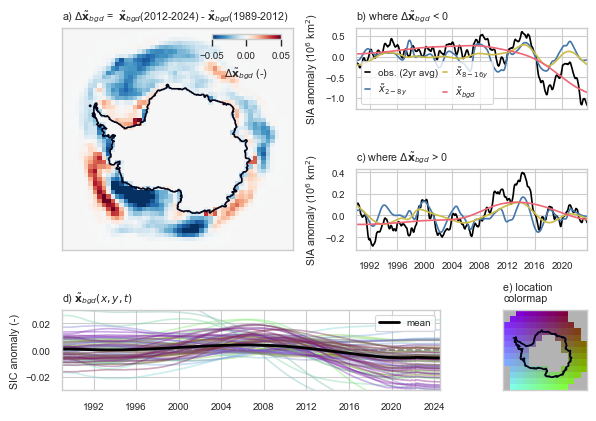

In [34]:
fig = plt.figure(figsize=(6, 4.25))
ax1 = plt.subplot2grid((3, 4), (0, 0), rowspan=2, colspan=2)
ax2 = plt.subplot2grid((3, 4), (0, 2), colspan=2)
ax3 = plt.subplot2grid((3, 4), (1, 2), colspan=2)
ax4 = plt.subplot2grid((3, 4), (2, 0), colspan=3)
ax5 = plt.subplot2grid((3, 4), (2, 3))

loss_colors = ["xkcd:blue", "xkcd:burnt red"]

# Map
ax = ax1
cmap = plt.colormaps["RdBu_r"]
levels = [-0.2, -0.1, -0.05, -0.01, 0.01, 0.05, 0.1, 0.2]

im = ax.pcolormesh(
    ds_background.y,
    ds_background.x,
    diff,
    cmap=cmap,
    vmin=-0.05,
    vmax=0.05,
    shading="nearest",
    rasterized=True,
)
ax.set_facecolor("0.8")
ax.grid(False)
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_yticklabels([])
ax.set_xticklabels([])
ax.contour(ds_mask.y, ds_mask.x, ds_mask.mask, [0, 1])
ax.set_title(
    r"a) $\Delta\tilde{\mathbf{x}}_{bgd}$ =  $\tilde{\mathbf{x}}_{bgd}$(2012-2024) - $\tilde{\mathbf{x}}_{bgd}$(1989-2012)",
    loc="left",
)

axins = ax.inset_axes([0.65, 0.95, 0.3, 0.025], xticklabels=[], yticklabels=[])
cbar = fig.colorbar(im, cax=axins, orientation="horizontal")
cbar.set_label(r"$\Delta\tilde{\mathbf{x}}_{bgd}$ (-)")

# Time series
ax = ax2
loss_obs = ds_obs.where(diff < 0).concentration
loss_obs = xr.where(np.isnan(loss_obs), 0, loss_obs)
loss_obs = loss_obs.integrate("x_km").integrate("y_km") / 10**6
loss_obs = loss_obs.rolling(
    time=int(2 * 365 // 15), center=True, min_periods=int(2 * 365 // 15)
).mean()
ax.plot(
    loss_obs.time,
    loss_obs - loss_obs.mean(dim="time"),
    color="k",
    label="obs. (2yr avg)",
)

loss = ds_xr_bands.where(diff < 0).where(ds_xr_bands.bands > 2.3, drop=True)
loss = xr.where(np.isnan(loss), 0, loss)
loss = loss.integrate("x_km").integrate("y_km") / 10**6

band_ranges = [(2.5, 8), (8, 16)]
band_labels = [r"$\tilde{x}_{2-8y}$", r"$\tilde{x}_{8-16y}$"]
for n_band, b in enumerate(band_ranges):
    label = band_labels[n_band]
    b1, b2 = b
    ds = loss.where((loss.bands > b1) & (loss.bands < b2), drop=True)
    ax.plot(ds.time, ds.sum(dim="bands"), color=tol_bright_reorder[n_band], label=label)

loss = ds_background.where(diff < 0) + ds_xr_bands.where(diff < 0).sel(
    bands=23, method="nearest"
)
loss = xr.where(np.isnan(loss), 0, loss)
loss = loss.integrate("x_km").integrate("y_km") / 10**6
ax.plot(
    loss.time,
    loss - loss.mean(dim="time"),
    color=tol_bright_reorder[n_band + 1],
    label=r"$\tilde{x}_{bgd}$",
)

ax.set_ylabel("SIA anomaly (10$^6$ km$^2$)")
ax.set_title(r"b) where $\Delta\tilde{\mathbf{x}}_{bgd}$ < 0", loc="left")
ax.set_xticklabels([])
ax.set_xlim(loss_obs.dropna(dim="time").time[0], loss_obs.dropna(dim="time").time[-1])
ax.legend(
    ncols=2,
    labelspacing=0.5,
    columnspacing=0.5,
    handlelength=0.5,
    loc="lower left",
    bbox_to_anchor=(0, 0),
)

## -------------------------------------------------------------------
# Locations with a gain in x_bgd
ax = ax3
gain_obs = ds_obs.where(diff > 0).concentration
gain_obs = xr.where(np.isnan(gain_obs), 0, gain_obs)
gain_obs = gain_obs.integrate("x_km").integrate("y_km") / 10**6
gain_obs = gain_obs.rolling(
    time=int(2 * 365 // 15),
    center=True,
    min_periods=int(2 * 365 // 15),
).mean()
ax.plot(gain_obs.time, gain_obs - gain_obs.mean(dim="time"), color="k")

gain = ds_xr_bands.where(diff > 0).where(ds_xr_bands.bands > 2.3, drop=True)
gain = xr.where(np.isnan(gain), 0, gain)
gain = gain.integrate("x_km").integrate("y_km") / 10**6
for n_band, b in enumerate(band_ranges):
    label = band_labels[n_band]
    b1, b2 = b
    ds = gain.where((gain.bands > b1) & (gain.bands < b2), drop=True)
    ax.plot(ds.time, ds.sum(dim="bands"), color=tol_bright_reorder[n_band], label=label)

gain = ds_background.where(diff > 0) + ds_xr_bands.where(diff > 0).sel(
    bands=23, method="nearest"
)
gain = xr.where(np.isnan(gain), 0, gain)
gain = gain.integrate("x_km").integrate("y_km") / 10**6
ax.plot(gain.time, gain - gain.mean(dim="time"), color=tol_bright_reorder[n_band + 1])

ax.set_ylabel("SIA anomaly (10$^6$ km$^2$)")
ax.set_title(r"c) where $\Delta\tilde{\mathbf{x}}_{bgd}$ > 0", loc="left")
ax.set_xlim(gain_obs.dropna(dim="time").time[0], gain_obs.dropna(dim="time").time[-1])

## -------------------------------------------------------------------
# Time series of x_bgd at each point (aggregated)
ax = ax4
ax.axhline(0, ls="--", color="0.5")
for x in deviation.x:
    for y in deviation.y:
        ds = deviation.sel(x=x, y=y)
        if all(np.isnan(ds.concentration)) or mean.sel(x=x, y=y) < 0.05:
            continue
        ax.plot(ds.time, ds.concentration, color=ds.colors.values, alpha=0.4)
ax.set_title(r"d) $\tilde{\mathbf{x}}_{bgd}(x, y, t)$", loc="left")
ax.set_xlim(deviation.time[0], deviation.time[-1])
da = (
    deviation.mean(dim=("x", "y")) - deviation.mean(dim=("x", "y", "time"))
).concentration
ax.plot(da.time, da, color="k", lw=2, label="mean")
ax.set_ylabel("SIC anomaly (-)")
ax.legend(loc="upper right")
ax.set_ylim(-0.03, 0.03)

## -------------------------------------------------------------------
# Time series location colormap
ax = ax5
ax.grid(False)
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_yticklabels([])
ax.set_xticklabels([])
ax.pcolormesh(deviation.x, deviation.y, deviation.colors)
ax.contour(ds_mask.x, ds_mask.y, ds_mask.mask, [0, 1])
ax.set_title("e) location\ncolormap", loc="left")

plt.tight_layout()

os.chdir(dir_print)
fig.savefig("fig3.mrcost-x_bgd_spatial-patterns.png", dpi=300, bbox_inches="tight")
fig.savefig("fig3.mrcost-x_bgd_spatial-patterns.pdf", bbox_inches="tight")

# Discovering predictability of the annual cycle

## Data prep for this analysis

In [35]:
print("=" * 60)
print("Creating Figure 5...")
print("")

Creating Figure 5...



In [36]:
# Indicate a point
# point_label = "weddell-sea-permanent-ice"
# x_0 = 0.15
# y_0 = -0.15

point_label = "weddell-sea-margin"
x_0 = 0.25
y_0 = -0.15

# point_label = "amundsen-sea"
# x_0 = -0.15
# y_0 = -0.15

# Create data sets for the indicated point
ds_point_background = ds_background.sel(y=y_0, x=x_0, method="nearest")

ds_point_xr_bands = ds_xr_bands.sel(y=y_0, x=x_0, method="nearest")
xr_recon = ds_point_xr_bands.sum(dim="bands") + ds_point_background

xr_recon_annual = ds_point_xr_bands.where(ds_point_xr_bands.bands < 1.5, drop=True).sum(
    dim="bands"
)

xr_recon_inter = ds_point_xr_bands.where(ds_point_xr_bands.bands > 1.5, drop=True).sum(
    dim="bands"
)

ds_point_obs = ds_obs.concentration.sel(y=y_0, x=x_0, method="nearest")

ds_point_annual = ds_xr_bands.sel(y=y_0, x=x_0, method="nearest")
ds_point_annual = ds_point_annual.where(ds_point_annual.bands < 1.1, drop=True)

In [37]:
# Merge the individual bands (off harmonic bands)
other_bands = ds_point_annual.isel(bands=[1, 3, 5]).sum(dim="bands")
other_bands = other_bands.expand_dims(dim={"grouped_bands": ["other subannual"]})

# Select the annual harmonics
ds_point_band_plots = ds_point_annual.isel(bands=[0, 2, 4])
ds_point_band_plots = ds_point_band_plots.assign_coords(
    grouped_bands=("bands", ["1y", "0.5y", "0.25y"])
)

# Concatenate into a single dataset with more useful labels
ds_point_bands = xr.concat(
    [
        ds_point_band_plots.swap_dims({"bands": "grouped_bands"}).drop("bands"),
        other_bands,
    ],
    dim="grouped_bands",
)

## Predictable versus non-predictable components of annual cycle (Figure 5)

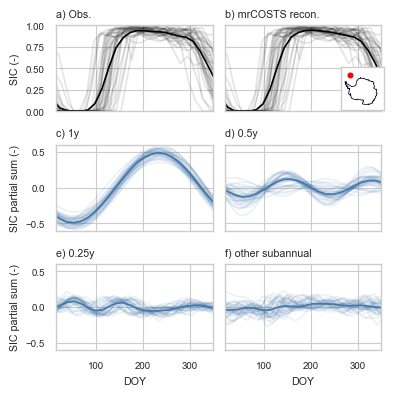

In [38]:
fig, axes = plt.subplots(3, 2, figsize=(4, 4), sharex=True)
day_bins = np.arange(0, 365, 15)
bin_labels = day_bins[:-1] + (day_bins[1:] - day_bins[:-1]) / 2

# -------------------------------------------------------------------
# Observed annual cycle
ax = axes[0, 0]
doy_grouped = ds_point_obs.groupby_bins(
    "time.dayofyear", day_bins, labels=bin_labels
).mean()
ax.plot(doy_grouped.dayofyear_bins, doy_grouped, color="k")
for y in np.arange(1989, 2024):
    ds = ds_point_obs.isel(time=(ds_point_obs.time.dt.year == y))
    ax.plot(ds.time.dt.dayofyear, ds, alpha=0.1, color="k")
ax.set_ylim(0, 1)
ax.set_title("")
ax.set_title(f"a) Obs.", loc="left")
ax.set_ylabel("SIC (-)")
ax.set_xlim(15, 365 - 15)
ax.set_xlabel("")

# -------------------------------------------------------------------
# Reconstructed annual cycle
ax = axes[0, 1]
doy_grouped = xr_recon.groupby_bins(
    "time.dayofyear", day_bins, labels=bin_labels
).mean()
ax.plot(doy_grouped.dayofyear_bins, doy_grouped, color="k")
for y in np.arange(1989, 2024):
    ds = ds_point_obs.isel(time=(ds_point_obs.time.dt.year == y))
    ax.plot(ds.time.dt.dayofyear, ds, alpha=0.1, color="k")
ax.set_ylim(0, 1)
ax.set_title("")
ax.set_title(f"b) mrCOSTS recon.", loc="left")
ax.set_xlim(15, 365 - 15)
ax.set_xlabel("")
ax.set_yticklabels([])

# -------------------------------------------------------------------
# Individual band's annual cycle
ax_array = axes.flatten()[2:]
for nband, band in enumerate(ds_point_bands.grouped_bands):
    ax = ax_array[nband]
    ds_band = ds_point_bands.sel(grouped_bands=band)
    doy_grouped = ds_band.groupby_bins(
        "time.dayofyear", day_bins, labels=bin_labels
    ).mean()
    ax.plot(doy_grouped.dayofyear_bins, doy_grouped, color=tol_bright_reorder[0])
    for y in np.arange(1989, 2024):
        ds_yc = ds_band.isel(time=(other_bands.time.dt.year == y))
        ax.plot(ds_yc.time.dt.dayofyear, ds_yc, alpha=0.1, color=tol_bright_reorder[0])
    ax.set_ylim(-0.6, 0.6)
    ax.set_xlim(15, 365 - 15)
    ax.set_title(f"{alphabet[nband + 2]}) {band.values}", loc="left")
    ax.set_xlabel("")
    if not ax.get_subplotspec().is_first_col():
        ax.set_yticklabels([])
axes[1, 0].set_ylabel("SIC partial sum (-)")
axes[2, 0].set_ylabel("SIC partial sum (-)")
axes[2, 0].set_xlabel("DOY")
axes[2, 1].set_xlabel("DOY")

# -------------------------------------------------------------------
# Inset map axis
ax_map = axes[0, 1].inset_axes([0.63, 0.01, 0.5, 0.5])
ax_map.set_yticks([])
ax_map.set_yticklabels([])
ax_map.set_xticks([])
ax_map.set_xticklabels([])
ax_map.contour(ds_mask.x, ds_mask.y, ds_mask.mask, [0, 1], linewidths=0.5)
ax_map.scatter(y_0, x_0, 50, color="r", marker=".")
ax_map.patch.set_edgecolor("k")
ax_map.patch.set_linewidth(0.5)
ax_map.set_aspect("equal", adjustable="box")

fig.tight_layout()

os.chdir(dir_print)
fig.savefig(
    f"fig5.mrcosts-diagnosis_point.{point_label}.png", dpi=300, bbox_inches="tight"
)
fig.savefig(f"fig5.mrcosts-diagnosis_point.{point_label}.pdf", bbox_inches="tight")

In [39]:
# Create spatially averaged datasets
ds_point_background = ds_background.mean(dim=["x", "y"])

ds_point_xr_bands = ds_xr_bands.mean(dim=["x", "y"])
xr_recon = ds_point_xr_bands.sum(dim="bands") + ds_point_background

xr_recon_annual = ds_point_xr_bands.where(ds_point_xr_bands.bands < 1.5, drop=True).sum(
    dim="bands"
)

xr_recon_inter = ds_point_xr_bands.where(ds_point_xr_bands.bands > 1.5, drop=True).sum(
    dim="bands"
)

ds_point_obs = ds_obs.concentration.mean(dim=["x", "y"])


ds_point_annual = ds_xr_bands.mean(dim=["x", "y"])
ds_point_annual = ds_point_annual.where(ds_point_annual.bands < 1.1, drop=True)

# Merge the individual bands (off harmonic bands)
other_bands = ds_point_annual.isel(bands=[1, 3, 5]).sum(dim="bands")
other_bands = other_bands.expand_dims(dim={"grouped_bands": ["other subannual"]})

# Select the annual harmonics
ds_point_band_plots = ds_point_annual.isel(bands=[0, 2, 4])
ds_point_band_plots = ds_point_band_plots.assign_coords(
    grouped_bands=("bands", ["1y", "0.5y", "0.25y"])
)

# Concatenate into a single dataset with more useful labels
ds_point_bands = xr.concat(
    [
        ds_point_band_plots.swap_dims({"bands": "grouped_bands"}).drop("bands"),
        other_bands,
    ],
    dim="grouped_bands",
)

ds_predictable = ds_point_bands.sel(grouped_bands=["1y", "0.5y"]).sum(
    dim="grouped_bands"
)
ds_unpredictable = ds_point_bands.sel(grouped_bands=["0.25y", "other subannual"]).sum(
    dim="grouped_bands"
)

# Subpanels of Figure 1

In [40]:
print("=" * 60)
print("Creating Subpanels for Figure 1...")
print("")

Creating Subpanels for Figure 1...



In [41]:
sns.set_context("talk", font_scale=0.8)

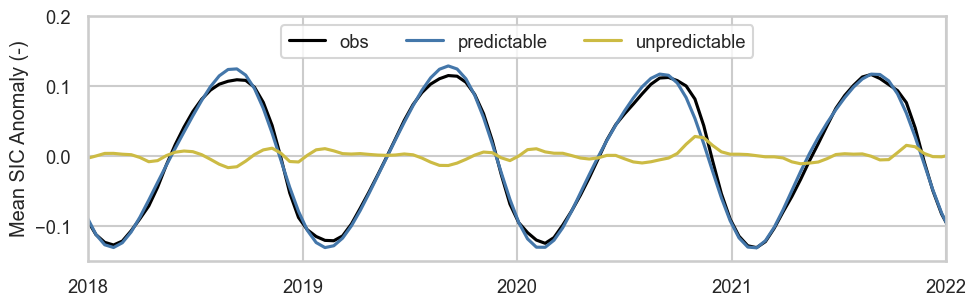

In [42]:
import matplotlib.dates as mdates

years = mdates.YearLocator()  # every year
years_fmt = mdates.DateFormatter("%Y")

fig, ax = plt.subplots(1, 1, figsize=(10, 3.3))

# ax.plot(ds_point_obs.time, ds_point_obs - ds_point_obs.mean(dim="time"), color="k")
ax.plot(ds_point_obs.time, ds_predictable + ds_unpredictable, color="k", label="obs")
ax.plot(
    ds_predictable.time,
    ds_predictable,
    color=tol_bright_reorder[0],
    label="predictable",
)
ax.plot(
    ds_unpredictable.time,
    ds_unpredictable,
    color=tol_bright_reorder[1],
    label="unpredictable",
)
ax.legend(ncol=3, loc="upper center")
ax.set_xlim(pd.Timestamp("2018"), pd.Timestamp("2022"))
ax.set_ylim(-0.15, 0.2)
ax.set_ylabel("Mean SIC Anomaly (-)")

ax.xaxis.set_major_locator(years)
ax.xaxis.set_major_formatter(years_fmt)

fig.tight_layout()

os.chdir(dir_print)
fig.savefig(f"fig1.mrcosts-predictability-diagnosis.png", dpi=300, bbox_inches="tight")
fig.savefig(f"fig1.mrcosts-predictability-diagnosis.pdf", bbox_inches="tight")

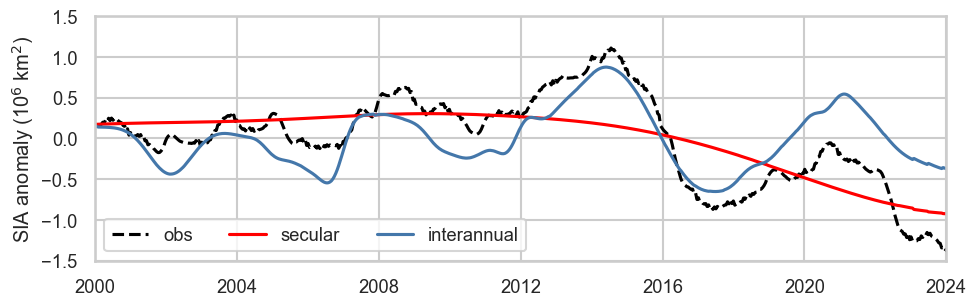

In [43]:
fig, ax = plt.subplots(1, 1, figsize=(10, 3.3), sharex=True)

# --------------------------------------------------------------------------------
# Band components
monthly_anom_rolling.plot(ax=ax, label="obs", color="k", ls="--")
xr_background_edit.plot(ax=ax, label="secular", color="r")
(xr_all_interannual).plot(
    ax=ax,
    label="interannual",
    color=tol_bright_reorder[0],
)

ax.set_title("")
ax.legend(ncols=5, loc="lower left")
ax.set_ylabel("SIA anomaly (10$^6$ km$^2$)")
ax.set_xlabel("")
ax.set_xlim(pd.Timestamp("2000-01-01"), pd.Timestamp("2024-01-01"))
ax.set_ylim(-1.5, 1.5)

fig.tight_layout()

os.chdir(dir_print)
fig.savefig("fig1.mrCOSTS-diagnostic.long-term.fig1.png", dpi=300, bbox_inches="tight")
fig.savefig("fig1.mrCOSTS-diagnostic.long-term.fig1.pdf", bbox_inches="tight")